In [1]:
# 0) Gemini API keys + experiment config (run this first)
from getpass import getpass
from google.colab import drive

drive.mount("/content/drive")

GEMINI_API_KEY_1 = getpass("Gemini API key #1: ").strip()
GEMINI_API_KEY_2 = getpass("Gemini API key #2: ").strip()
GEMINI_API_KEY_3 = getpass("Gemini API key #3: ").strip()
GEMINI_API_KEYS = [GEMINI_API_KEY_1, GEMINI_API_KEY_2, GEMINI_API_KEY_3]

assert all(GEMINI_API_KEYS), "Nhap dung 3 Gemini API keys de chay round-robin judge."
assert len(set(GEMINI_API_KEYS)) == len(GEMINI_API_KEYS), "Ba API keys nen khac nhau de round-robin dung muc tieu."

# Gemini judge: 3 keys x 15 RPM / 500 RPD ~= 45 RPM / 1500 RPD total.
GEMINI_MODEL = "gemini-3.1-flash-lite-preview"
GEMINI_RPM_LIMIT_PER_KEY = 15
GEMINI_RPD_LIMIT_PER_KEY = 500
GEMINI_THINKING_LEVEL = "MEDIUM"  # Flash-Lite supports MINIMAL, LOW, MEDIUM, HIGH.
GEMINI_RATE_LIMIT_COOLDOWN_SEC = 60

# L4-friendly VLM fine-tune defaults.
BASE_MODEL = "unsloth/Qwen3.5-4B"  # Text-image-to-text model from the project plan.
MAX_SEQ_LENGTH = 4096
LOAD_IN_4BIT = False
LORA_DROPOUT = 0.0
LEARNING_RATE = 1e-5
PER_DEVICE_BATCH = 4
GRAD_ACCUM = 2
GEN_MAX_NEW_TOKENS = 256
CHECKPOINT_EVERY = 10

# Flow controls. Default flow: fixed50 config selection, then final full train/eval.
RUN_MODEL_SANITY_GENERATION = True
RUN_BASELINE_GENERATION = True
RUN_CONFIG_SWEEP = True
RUN_FINAL_FULL_TRAIN = True
RUN_FINAL_FULL_EVAL = True
RUN_GEMINI_JUDGE = True
FORCE_RERUN = False

# Legacy single-config variables are kept for compatibility with older cells/output names.
LORA_R = 16
LORA_ALPHA = 32
NUM_EPOCHS = 1
JUDGE_SCOPE = "fixed50"

# Fixed50 config sweep. Enable r64 only if r16 is not good enough.
CONFIG_SWEEP = [
    {"name": "r16_e1", "r": 16, "alpha": 32, "dropout": 0.0, "lr": 1e-5, "epochs": 1, "batch": 4, "grad_accum": 2, "enabled": True},
    {"name": "r16_e2", "r": 16, "alpha": 32, "dropout": 0.0, "lr": 1e-5, "epochs": 2, "batch": 4, "grad_accum": 2, "enabled": False},
    {"name": "r64_e1", "r": 64, "alpha": 128, "dropout": 0.0, "lr": 1e-5, "epochs": 1, "batch": 4, "grad_accum": 2, "enabled": False},
]

# Dataset download/cache. You can pre-download with:
# !gdown 1uXvOVhwo8j944gRYBqpzxKZn0_EqjdzL -O /content/drive/MyDrive/eduvidqa/ft_context_vlm_clean.tar.gz
DATA_ARCHIVE_FILE_ID = "1uXvOVhwo8j944gRYBqpzxKZn0_EqjdzL"
DATA_ARCHIVE_URL = f"https://drive.google.com/uc?id={DATA_ARCHIVE_FILE_ID}"
DATA_ARCHIVE_FILENAME = "ft_context_vlm_clean.tar.gz"
DRIVE_WORKDIR = "/content/drive/MyDrive/eduvidqa_qwen35_vl"
DRIVE_DATA_CACHE = "/content/drive/MyDrive/eduvidqa"
LOCAL_DOWNLOAD_DIR = "/content"
DATA_ARCHIVE_CANDIDATES = [
    f"{DRIVE_DATA_CACHE}/{DATA_ARCHIVE_FILENAME}",
    f"{LOCAL_DOWNLOAD_DIR}/{DATA_ARCHIVE_FILENAME}",
    f"/content/A20-App-049/data/eduvidqa/{DATA_ARCHIVE_FILENAME}",
]
DATA_ARCHIVE = None
WORKDIR = DRIVE_WORKDIR
OUTPUT_DIR = f"{WORKDIR}/outputs"
SEED = 42

print("Gemini keys loaded:", len(GEMINI_API_KEYS))
print("Effective judge limit:", len(GEMINI_API_KEYS) * GEMINI_RPM_LIMIT_PER_KEY, "RPM,", len(GEMINI_API_KEYS) * GEMINI_RPD_LIMIT_PER_KEY, "RPD")
print("Gemini judge:", {"model": GEMINI_MODEL, "thinking": GEMINI_THINKING_LEVEL})
print("Config sweep:", [cfg for cfg in CONFIG_SWEEP if cfg.get("enabled", True)])
print("Final full train/eval:", RUN_FINAL_FULL_TRAIN, RUN_FINAL_FULL_EVAL)
print("Drive output dir:", OUTPUT_DIR)


Mounted at /content/drive
Gemini API key #1: ··········
Gemini API key #2: ··········
Gemini API key #3: ··········
Gemini keys loaded: 3
Effective judge limit: 45 RPM, 1500 RPD
Gemini judge: {'model': 'gemini-3.1-flash-lite-preview', 'thinking': 'MEDIUM'}
Config sweep: [{'name': 'r16_e1', 'r': 16, 'alpha': 32, 'dropout': 0.0, 'lr': 1e-05, 'epochs': 1, 'enabled': True}, {'name': 'r16_e2', 'r': 16, 'alpha': 32, 'dropout': 0.0, 'lr': 1e-05, 'epochs': 2, 'enabled': True}, {'name': 'r64_e1', 'r': 64, 'alpha': 128, 'dropout': 0.0, 'lr': 1e-05, 'epochs': 1, 'enabled': True}]
Final full train/eval: True True
Drive output dir: /content/drive/MyDrive/eduvidqa_qwen35_vl/outputs


# EduVidQA Qwen3.5-VL L4 Fine-Tune + Gemini Judge

Notebook này thay cho hướng script/local-host:

- Fine-tune trên Colab **L4** bằng QLoRA/LoRA style tutor grounded theo **frame + transcript**.
- Judge chính dùng **Gemini API round-robin 3 keys** với `gemini-3.1-flash-lite-preview`, JSON output, thinking lấy từ `GEMINI_THINKING_LEVEL` mặc định `MEDIUM`.
- Dataset clean tarball được tải tự động bằng `gdown` từ Google Drive link cấu hình trong cell 0.
- Outputs lưu thẳng vào `/content/drive/MyDrive/eduvidqa_qwen35_vl/outputs`: adapters, trainer checkpoints, predictions, judge JSONL, summary.
- Tổng call dự kiến `<1000`: base + FT trên `synthetic_test_clean` 131 và `real_world_test_clean` 254 là khoảng 770 judge calls, nằm dưới tổng 3 keys x 500 RPD nếu quota/key còn sạch.
- Flow chính: project split 90/10 theo `video_id` để chọn config, sau đó train final full `synthetic_train_clean` bằng config tốt nhất.

Paper wording dùng trong report: **paper-inspired / paper-aligned VLM subset**, vì subset này theo format 1 frame + transcript quanh timestamp + question, nhưng là clean/recovered timestamp subset, không phải exact official full split.

In [2]:
# 1) Install dependencies - run full reinstall only when needed
import importlib.util

FORCE_REINSTALL_DEPS = False  # True chỉ khi muốn clean install lại
INSTALL_QWEN_FAST_PATH = False  # bật True nếu muốn thử lại causal-conv1d/flash-linear-attention

def has_module(name):
    return importlib.util.find_spec(name) is not None

need_install = FORCE_REINSTALL_DEPS or not (
    has_module("unsloth")
    and has_module("trl")
    and has_module("transformers")
    and has_module("peft")
    and has_module("google.genai")
    and has_module("gdown")
)

if need_install:
    !pip install uv

    if FORCE_REINSTALL_DEPS:
        !pip uninstall -y unsloth unsloth_zoo trl transformers peft accelerate bitsandbytes Pillow pillow

    force_flags = "--upgrade --force-reinstall" if FORCE_REINSTALL_DEPS else ""

    !uv pip install --system --no-cache {force_flags} "unsloth[colab-new]" unsloth_zoo
    !uv pip install --system --no-cache Pillow==11.3.0 datasets pandas scikit-learn google-genai gdown

    print("Dependencies installed. If this changed packages, restart runtime once, then rerun from cell 0.")
else:
    print("Dependencies already installed; skipping install.")

if INSTALL_QWEN_FAST_PATH:
    print("Installing optional Qwen fast path deps...")
    try:
        !uv pip install --system --no-cache causal-conv1d flash-linear-attention
        print("Qwen fast path deps installed.")
    except Exception as exc:
        print("WARNING: Could not install Qwen fast path deps; continuing with torch fallback.")
        print(exc)
else:
    print("Skipping optional Qwen fast path deps.")

Dependencies already installed; skipping install.
Skipping optional Qwen fast path deps.


In [3]:
# 2) Imports + GPU check
import json
import math
import os
import random
import re
import subprocess
import tarfile
import time
from collections import Counter, defaultdict
from pathlib import Path

import pandas as pd
import torch
from datasets import Dataset
from PIL import Image

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    subprocess.run(["nvidia-smi"], check=False)

CUDA available: True


In [4]:
!gdown 1uXvOVhwo8j944gRYBqpzxKZn0_EqjdzL -O /content/drive/MyDrive/eduvidqa/ft_context_vlm_clean.tar.gz

Downloading...
From (original): https://drive.google.com/uc?id=1uXvOVhwo8j944gRYBqpzxKZn0_EqjdzL
From (redirected): https://drive.google.com/uc?id=1uXvOVhwo8j944gRYBqpzxKZn0_EqjdzL&confirm=t&uuid=5eee7732-67a9-4bb8-b0a2-a355fb73bed5
To: /content/drive/MyDrive/eduvidqa/ft_context_vlm_clean.tar.gz
100% 188M/188M [00:01<00:00, 150MB/s]


In [5]:
# 3) Locate/cache and extract clean EduVidQA VLM dataset to local /content
# Outputs/checkpoints still save to Drive via OUTPUT_DIR.

root = Path("/content/eduvidqa_qwen35_vl_runtime")
root.mkdir(parents=True, exist_ok=True)

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
Path(DRIVE_DATA_CACHE).mkdir(parents=True, exist_ok=True)
Path(LOCAL_DOWNLOAD_DIR).mkdir(parents=True, exist_ok=True)

drive_cache_path = Path(DRIVE_DATA_CACHE) / DATA_ARCHIVE_FILENAME
local_download_path = Path(LOCAL_DOWNLOAD_DIR) / DATA_ARCHIVE_FILENAME

# You already downloaded with:
# !gdown 1uXvOVhwo8j944gRYBqpzxKZn0_EqjdzL -O /content/drive/MyDrive/eduvidqa/ft_context_vlm_clean.tar.gz

if DATA_ARCHIVE is None:
    for candidate in DATA_ARCHIVE_CANDIDATES:
        candidate_path = Path(candidate)
        if candidate_path.exists():
            DATA_ARCHIVE = candidate_path
            break

if DATA_ARCHIVE is None:
    raise FileNotFoundError(
        "Dataset archive not found. Run this first:\n"
        "!mkdir -p /content/drive/MyDrive/eduvidqa\n"
        "!gdown 1uXvOVhwo8j944gRYBqpzxKZn0_EqjdzL "
        "-O /content/drive/MyDrive/eduvidqa/ft_context_vlm_clean.tar.gz"
    )

DATA_ARCHIVE = Path(DATA_ARCHIVE)
assert DATA_ARCHIVE.exists(), (
    f"Dataset archive not found: {DATA_ARCHIVE}. "
    "Check Drive mount and file path."
)

print("Dataset archive:", DATA_ARCHIVE)
print("Extracting/using local runtime root:", root)
print("Outputs will be saved under:", OUTPUT_DIR)

extract_root = root / "dataset"
extract_root.mkdir(parents=True, exist_ok=True)

summary_path = extract_root / "ft_context_vlm_clean" / "summary.json"
if not summary_path.exists():
    print("Extracting dataset to local /content runtime...")
    with tarfile.open(DATA_ARCHIVE, "r:gz") as archive:
        archive.extractall(extract_root)
else:
    print("Dataset already extracted locally.")

dataset_root = extract_root / "ft_context_vlm_clean"
print("Dataset root:", dataset_root)
print((dataset_root / "summary.json").read_text()[:1000])

Dataset archive: /content/drive/MyDrive/eduvidqa/ft_context_vlm_clean.tar.gz
Extracting/using local runtime root: /content/eduvidqa_qwen35_vl_runtime
Outputs will be saved under: /content/drive/MyDrive/eduvidqa_qwen35_vl/outputs
Extracting dataset to local /content runtime...


/tmp/ipykernel_4384/3453960206.py:49: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  archive.extractall(extract_root)


Dataset root: /content/eduvidqa_qwen35_vl_runtime/dataset/ft_context_vlm_clean
{
  "samples": 4103,
  "frames_generated": 4103,
  "skipped": 212,
  "splits": {
    "synthetic_train": 3718,
    "synthetic_test": 131,
    "real_world_test": 254
  },
  "window_seconds": 120.0,
  "recover_answer_timestamps": true,
  "drop_quality_flags": [
    "short_answer",
    "synthetic_rewrite_style"
  ]
}


In [6]:
# 4) Load records, create project split, and fixed_eval_50

def read_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

synthetic_train = read_jsonl(dataset_root / "synthetic_train.jsonl")
synthetic_test = read_jsonl(dataset_root / "synthetic_test.jsonl")
real_world_test = read_jsonl(dataset_root / "real_world_test.jsonl")

print("synthetic_train", len(synthetic_train))
print("synthetic_test", len(synthetic_test))
print("real_world_test", len(real_world_test))
print("all clean", len(synthetic_train) + len(synthetic_test) + len(real_world_test))


def split_by_video_id(records, train_ratio=0.90, seed=42):
    grouped = defaultdict(list)
    for row in records:
        grouped[row["video_id"]].append(row)
    groups = list(grouped.items())
    rng = random.Random(seed)
    rng.shuffle(groups)
    target = round(len(records) * train_ratio)
    train, val = [], []
    for idx, (_, rows) in enumerate(groups):
        keep_val_possible = (len(groups) - idx) > 1
        if len(train) < target and keep_val_possible:
            train.extend(rows)
        else:
            val.extend(rows)
    assert train and val
    assert {r["video_id"] for r in train}.isdisjoint({r["video_id"] for r in val})
    return train, val

project_train, project_val = split_by_video_id(synthetic_train, seed=SEED)
print("project_train", len(project_train), "project_val", len(project_val))
print("video overlap", len({r['video_id'] for r in project_train} & {r['video_id'] for r in project_val}))

HARD_KEYWORDS = ("formula", "equation", "matrix", "gradient", "derivative", "graph", "plot", "diagram", "figure", "visual", "slide", "shown", "frame", "image")

def is_hard(row):
    text = " ".join(str(row.get(k, "")) for k in ("question", "text_input", "answer", "title")).lower()
    return any(k in text for k in HARD_KEYWORDS)

def sample_rows(rows, n, seed):
    rows = list(rows)
    random.Random(seed).shuffle(rows)
    return rows[:min(n, len(rows))]

def with_bucket(row, bucket):
    out = dict(row)
    out["fixed_eval_bucket"] = bucket
    return out

fixed_eval_50 = []
seen = set()
for row in sample_rows(synthetic_test, 20, SEED + 1):
    fixed_eval_50.append(with_bucket(row, "synthetic")); seen.add(row["id"])
for row in sample_rows(real_world_test, 20, SEED + 2):
    if row["id"] not in seen:
        fixed_eval_50.append(with_bucket(row, "real_world")); seen.add(row["id"])
hard_pool = sample_rows([r for r in synthetic_test + real_world_test if is_hard(r)], 9999, SEED + 3)
hard_pool += sample_rows([r for r in synthetic_test + real_world_test if not is_hard(r)], 9999, SEED + 4)
for row in hard_pool:
    if sum(r["fixed_eval_bucket"] == "hard" for r in fixed_eval_50) >= 10:
        break
    if row["id"] not in seen:
        fixed_eval_50.append(with_bucket(row, "hard")); seen.add(row["id"])

print("fixed_eval_50", len(fixed_eval_50), Counter(r["fixed_eval_bucket"] for r in fixed_eval_50))

synthetic_train 3718
synthetic_test 131
real_world_test 254
all clean 4103
project_train 3364 project_val 354
video overlap 0
fixed_eval_50 50 Counter({'synthetic': 20, 'real_world': 20, 'hard': 10})


In [7]:
# 5) Prompt + true lazy dataset conversion for vision SFT
import gc
import json
from pathlib import Path
from PIL import Image, UnidentifiedImageError
from torch.utils.data import Dataset as TorchDataset
from tqdm.auto import tqdm

# Clear old partially-built objects from interrupted runs
for name in [
    "train_conversations",
    "val_conversations",
    "train_dataset",
    "val_dataset",
]:
    if name in globals():
        del globals()[name]
gc.collect()

SYSTEM_PROMPT = """You are an expert computer science educator answering questions about a lecture video.
Use only the provided frame and transcript window. If the context is insufficient, say so clearly.
Answer as a helpful tutor in one concise paragraph. Do not reveal hidden reasoning or <think> text."""

USER_TEMPLATE = """{system_prompt}

{record_text_input}

Answer the student question using the frame and transcript. Return only the final answer."""


def image_abs_path(row):
    return str(dataset_root / row["image"])


def make_instruction(row):
    return USER_TEMPLATE.format(
        system_prompt=SYSTEM_PROMPT,
        record_text_input=row["text_input"],
    )


def quick_filter_image_rows(records, split_name):
    good = []
    bad = []

    for row in tqdm(records, desc=f"Checking image files ({split_name})", unit="img"):
        path = Path(image_abs_path(row))
        exists = path.exists()
        size = path.stat().st_size if exists else 0

        if exists and size > 1024:
            good.append(row)
        else:
            bad.append({
                "id": row.get("id"),
                "split": row.get("split"),
                "video_id": row.get("video_id"),
                "image": row.get("image"),
                "path": str(path),
                "exists": exists,
                "size": size,
            })

    print(f"{split_name}: good={len(good)} bad={len(bad)}")

    if bad:
        bad_path = Path(OUTPUT_DIR) / f"bad_images_{split_name}.json"
        bad_path.parent.mkdir(parents=True, exist_ok=True)
        bad_path.write_text(
            json.dumps(bad, ensure_ascii=False, indent=2),
            encoding="utf-8",
        )
        print("Bad image log:", bad_path)
        print("First bad image:", bad[0])

    return good, bad


class EduVidQALazyConversationDataset(TorchDataset):
    def __init__(self, records, split_name):
        self.records = list(records)
        self.split_name = split_name

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        row = self.records[idx]
        image_path = image_abs_path(row)

        try:
            image = Image.open(image_path).convert("RGB")
        except (UnidentifiedImageError, OSError, ValueError) as exc:
            raise RuntimeError(
                f"Bad image in {self.split_name} at idx={idx}, "
                f"id={row.get('id')}, path={image_path}: {exc}"
            ) from exc

        return {
            "id": row["id"],
            "messages": [
                {
                    "role": "user",
                    "content": [
                        {"type": "image", "image": image},
                        {"type": "text", "text": make_instruction(row)},
                    ],
                },
                {
                    "role": "assistant",
                    "content": [{"type": "text", "text": row["answer"]}],
                },
            ],
        }


train_records_for_this_run = project_train
val_records_for_this_run = project_val

train_records_for_this_run, bad_train_images = quick_filter_image_rows(
    train_records_for_this_run,
    "train",
)

if val_records_for_this_run:
    val_records_for_this_run, bad_val_images = quick_filter_image_rows(
        val_records_for_this_run,
        "val",
    )
else:
    bad_val_images = []

assert train_records_for_this_run, "No valid training images remain after filtering."

train_dataset = EduVidQALazyConversationDataset(train_records_for_this_run, "train")
val_dataset = (
    EduVidQALazyConversationDataset(val_records_for_this_run, "val")
    if val_records_for_this_run
    else None
)

print("train_dataset:", len(train_dataset))
print("val_dataset:", len(val_dataset) if val_dataset is not None else "No eval dataset")
print("dataset type:", type(train_dataset))
print("IMPORTANT: this cell does not call Dataset.from_list and does not preload PIL images.")

Checking image files (train):   0%|          | 0/3364 [00:00<?, ?img/s]

train: good=3364 bad=0


Checking image files (val):   0%|          | 0/354 [00:00<?, ?img/s]

val: good=354 bad=0
train_dataset: 3364
val_dataset: 354
dataset type: <class '__main__.EduVidQALazyConversationDataset'>
IMPORTANT: this cell does not call Dataset.from_list and does not preload PIL images.


dict_keys(['id', 'messages'])
image
<class 'PIL.Image.Image'>


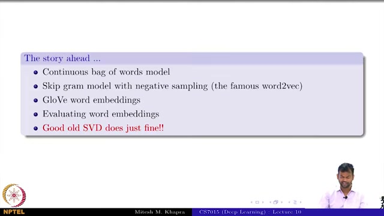

In [8]:
sample = train_dataset[0]
print(sample.keys())
print(sample["messages"][0]["content"][0]["type"])
print(type(sample["messages"][0]["content"][0]["image"]))
sample["messages"][0]["content"][0]["image"].resize((384, 216))

In [9]:
# 6) Model loading, generation, training, and file helpers
import gc
import inspect
from tqdm.auto import tqdm

# IMPORTANT: import Unsloth before TRL so Unsloth can patch the trainer/model stack.
from unsloth import FastVisionModel
from trl import SFTConfig, SFTTrainer
from peft import PeftModel
from unsloth.trainer import UnslothVisionDataCollator

torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision("high")

OUTPUT_ROOT = Path(OUTPUT_DIR)
BASELINE_DIR = OUTPUT_ROOT / "baseline"
SWEEP_DIR = OUTPUT_ROOT / "sweeps"
FINAL_DIR = OUTPUT_ROOT / "final"
for _d in [BASELINE_DIR, SWEEP_DIR, FINAL_DIR]:
    _d.mkdir(parents=True, exist_ok=True)


def clear_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def write_json(path, data):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, ensure_ascii=False, indent=2), encoding="utf-8")


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def write_jsonl(path, rows):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        for row in rows:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")


def read_jsonl_safe(path):
    path = Path(path)
    if not path.exists():
        return []
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def enabled_sweep_configs():
    return [dict(cfg) for cfg in CONFIG_SWEEP if cfg.get("enabled", True)]


def load_base_model():
    print("Loading base model:", BASE_MODEL)
    model, processor = FastVisionModel.from_pretrained(
        model_name=BASE_MODEL,
        max_seq_length=MAX_SEQ_LENGTH,
        load_in_4bit=LOAD_IN_4BIT,
        fast_inference=False,
        gpu_memory_utilization=0.80,
    )
    print("Processor:", type(processor))
    print("Tokenizer:", type(processor.tokenizer))
    return model, processor


def load_model_with_adapter(adapter_dir):
    model, processor = load_base_model()
    model = PeftModel.from_pretrained(model, str(adapter_dir))
    return model, processor


def attach_lora(model, cfg):
    return FastVisionModel.get_peft_model(
        model,
        finetune_vision_layers=False,
        finetune_language_layers=True,
        finetune_attention_modules=True,
        finetune_mlp_modules=True,
        r=int(cfg["r"]),
        lora_alpha=int(cfg["alpha"]),
        lora_dropout=float(cfg.get("dropout", LORA_DROPOUT)),
        bias="none",
        random_state=SEED,
        use_rslora=False,
        loftq_config=None,
        use_gradient_checkpointing="unsloth",
    )


def eval_records(scope):
    if scope == "fixed50":
        return fixed_eval_50
    if scope == "full":
        return synthetic_test + real_world_test
    raise ValueError(f"Unknown eval scope: {scope}")


def strip_thinking(text):
    return re.sub(r"<think\b[^>]*>.*?</think>", "", text or "", flags=re.S | re.I).strip()


def processor_inputs(processor, image, text_prompt):
    try:
        return processor(
            images=image,
            text=text_prompt,
            add_special_tokens=False,
            return_tensors="pt",
        ).to("cuda")
    except TypeError:
        try:
            return processor(
                text=[text_prompt],
                images=[image],
                videos=[],
                padding=True,
                return_tensors="pt",
            ).to("cuda")
        except TypeError:
            return processor(
                image,
                text_prompt,
                add_special_tokens=False,
                return_tensors="pt",
            ).to("cuda")


def generate_one(model, processor, row, max_new_tokens=GEN_MAX_NEW_TOKENS, temperature=0.1, top_p=0.9):
    image = Image.open(image_abs_path(row)).convert("RGB")
    messages = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": make_instruction(row)}]}]

    try:
        text_prompt = processor.tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
            enable_thinking=False,
        )
    except TypeError:
        text_prompt = processor.tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )

    inputs = processor_inputs(processor, image, text_prompt)
    input_len = inputs["input_ids"].shape[-1]

    t0 = time.perf_counter()
    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=temperature > 0,
            temperature=temperature,
            top_p=top_p,
            use_cache=True,
        )

    latency = time.perf_counter() - t0
    raw_answer = processor.tokenizer.decode(output_ids[0][input_len:], skip_special_tokens=True)
    clean_answer = strip_thinking(raw_answer)

    return {
        "id": row["id"],
        "split": row["split"],
        "raw_generated_answer": raw_answer,
        "generated_answer": clean_answer,
        "had_think_raw": bool(re.search(r"<think\b", raw_answer or "", flags=re.I)),
        "latency_sec": round(latency, 3),
        "output_tokens": int(output_ids.shape[-1] - input_len),
    }


def generate_predictions(model, processor, rows, out_path, label, force=False):
    out_path = Path(out_path)
    predictions = [] if force else read_jsonl_safe(out_path)
    done = {row["id"] for row in predictions}
    if predictions and len(done) == len(rows):
        print(f"SKIP generation {label}: {out_path} ({len(predictions)} rows)")
        return predictions

    try:
        FastVisionModel.for_inference(model)
    except Exception as exc:
        print("FastVisionModel.for_inference fallback to model.eval():", repr(exc))
    model.eval()
    for row in tqdm(rows, desc=f"Generate {label}", unit="sample"):
        if row["id"] in done:
            continue
        predictions.append(generate_one(model, processor, row))
        done.add(row["id"])
        if len(predictions) % CHECKPOINT_EVERY == 0:
            write_jsonl(out_path, predictions)
    write_jsonl(out_path, predictions)
    print("saved", len(predictions), out_path)
    return predictions


def _ensure_legacy_eos_token_if_needed(model, processor):
    # Fallback only for unpatched newer TRL path. It makes Unsloth's '<EOS_TOKEN>' default valid.
    token = "<EOS_TOKEN>"
    token_id = processor.tokenizer.convert_tokens_to_ids(token)
    if token_id is not None and token_id != processor.tokenizer.unk_token_id:
        return
    added = processor.tokenizer.add_special_tokens({"additional_special_tokens": [token]})
    if added:
        model.resize_token_embeddings(len(processor.tokenizer))
        print(f"Added fallback special token {token!r} for TRL compatibility.")


def train_adapter(cfg, train_records, val_records, run_dir, run_label, force=False):
    run_dir = Path(run_dir)
    adapter_dir = run_dir / "adapter"
    trainer_dir = run_dir / "trainer"
    done_marker = adapter_dir / "adapter_config.json"

    if done_marker.exists() and not force:
        print(f"SKIP training {run_label}: adapter exists at {adapter_dir}")
        return adapter_dir, None

    clear_cuda()
    model, processor = load_base_model()
    model = attach_lora(model, cfg)
    FastVisionModel.for_training(model)

    train_ds = EduVidQALazyConversationDataset(train_records, f"{run_label}_train")
    val_ds = EduVidQALazyConversationDataset(val_records, f"{run_label}_val") if val_records else None
    has_eval = val_ds is not None and len(val_ds) > 0

    args = SFTConfig(
        per_device_train_batch_size=PER_DEVICE_BATCH,
        gradient_accumulation_steps=GRAD_ACCUM,
        num_train_epochs=int(cfg["epochs"]),
        learning_rate=float(cfg.get("lr", LEARNING_RATE)),
        warmup_steps=10,
        logging_steps=10,
        eval_strategy="steps" if has_eval else "no",
        eval_steps=100 if has_eval else None,
        save_strategy="steps",
        save_steps=200,
        save_total_limit=2,
        optim="adamw_8bit",
        weight_decay=0.001,
        lr_scheduler_type="cosine",
        max_grad_norm=0.3,
        seed=SEED,
        output_dir=str(trainer_dir),
        report_to="none",
        remove_unused_columns=False,
        dataset_text_field="",
        dataset_kwargs={"skip_prepare_dataset": True},
        max_length=MAX_SEQ_LENGTH,
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
    )

    collator = UnslothVisionDataCollator(model, processor)
    trainer_kwargs = {
        "model": model,
        "data_collator": collator,
        "train_dataset": train_ds,
        "eval_dataset": val_ds if has_eval else None,
        "args": args,
    }

    sig = inspect.signature(SFTTrainer.__init__)
    if "tokenizer" in sig.parameters:
        trainer_kwargs["tokenizer"] = processor
        print("SFTTrainer mode: Unsloth patched tokenizer=processor")
    else:
        _ensure_legacy_eos_token_if_needed(model, processor)
        trainer_kwargs["processing_class"] = processor.tokenizer
        print("SFTTrainer mode: TRL processing_class fallback")

    trainer = SFTTrainer(**trainer_kwargs)
    train_result = trainer.train()
    print(train_result)

    adapter_dir.mkdir(parents=True, exist_ok=True)
    model.save_pretrained(adapter_dir)
    processor.save_pretrained(adapter_dir)
    write_json(run_dir / "train_config.json", cfg)
    print("saved adapter:", adapter_dir)

    del trainer, model, processor
    clear_cuda()
    return adapter_dir, str(train_result)

print("Helpers ready. Enabled sweep configs:", enabled_sweep_configs())
print("SFTTrainer signature:", inspect.signature(SFTTrainer.__init__))


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
Helpers ready. Enabled sweep configs: [{'name': 'r16_e1', 'r': 16, 'alpha': 32, 'dropout': 0.0, 'lr': 1e-05, 'epochs': 1, 'enabled': True}, {'name': 'r16_e2', 'r': 16, 'alpha': 32, 'dropout': 0.0, 'lr': 1e-05, 'epochs': 2, 'enabled': True}, {'name': 'r64_e1', 'r': 64, 'alpha': 128, 'dropout': 0.0, 'lr': 1e-05, 'epochs': 1, 'enabled': True}]
SFTTrainer signature: (self, model, args=None, data_collator=None, train_dataset=None, eval_dataset=None, processing_class=None, compute_loss_func=None, compute_metrics=None, callbacks=None, optimizer_cls_and_kwargs=None, preprocess_logits_for_metrics=None, peft_config=None, formatting_func=None, **kwargs)


In [10]:
# 7) Rule metrics and experiment summary helpers

def answer_word_count(text):
    return len((text or "").split())


def compute_rule_metrics(predictions):
    if not predictions:
        return {}
    answers = [p.get("generated_answer", "") for p in predictions]
    no_think = [not bool(re.search(r"<think\b", a or "", flags=re.I)) for a in answers]
    raw_no_think = [not bool(p.get("had_think_raw", False)) for p in predictions]
    nonempty = [answer_word_count(strip_thinking(a)) > 0 for a in answers]
    latencies = [p.get("latency_sec") for p in predictions if p.get("latency_sec") is not None]
    tokens = [p.get("output_tokens") for p in predictions if p.get("output_tokens") is not None]
    return {
        "sample_count": len(predictions),
        "no_think_rate": sum(no_think) / len(no_think),
        "raw_no_think_rate": sum(raw_no_think) / len(raw_no_think),
        "empty_answer_rate": 1 - (sum(nonempty) / len(nonempty)),
        "answer_word_count_mean": sum(answer_word_count(strip_thinking(a)) for a in answers) / len(answers),
        "latency_sec_mean": sum(latencies) / len(latencies) if latencies else None,
        "output_tokens_mean": sum(tokens) / len(tokens) if tokens else None,
    }


def mean(xs):
    xs = [x for x in xs if x is not None]
    return sum(xs) / len(xs) if xs else None


def summarize_judge(rows):
    if not rows:
        return {}
    return {
        "judge_sample_count": len(rows),
        "entailment_score_mean": mean([float(r.get("entailment_score")) for r in rows if r.get("entailment_score") is not None]),
        "factqa_precision_mean": mean([float(r.get("factqa_precision")) for r in rows if r.get("factqa_precision") is not None]),
        "factqa_recall_mean": mean([float(r.get("factqa_recall")) for r in rows if r.get("factqa_recall") is not None]),
        "clarity_mean": mean([float(r.get("clarity")) for r in rows if r.get("clarity") is not None]),
        "groundedness_mean": mean([float(r.get("groundedness")) for r in rows if r.get("groundedness") is not None]),
        "hallucination_rate": mean([1.0 if r.get("hallucination_flag") else 0.0 for r in rows if "hallucination_flag" in r]),
    }


def paired_win_rate(base_rows, ft_rows):
    base = {r["id"]: r for r in base_rows}
    ft = {r["id"]: r for r in ft_rows}
    win = tie = lose = 0
    by_split = defaultdict(lambda: {"win": 0, "tie": 0, "lose": 0})
    for row_id in sorted(set(base) & set(ft)):
        b, f = base[row_id], ft[row_id]
        bp, fp = float(b.get("factqa_precision", 0)), float(f.get("factqa_precision", 0))
        bc, fc = float(b.get("clarity", 0)), float(f.get("clarity", 0))
        if fp > bp or (fp == bp and fc > bc):
            outcome = "win"; win += 1
        elif fp == bp and fc == bc:
            outcome = "tie"; tie += 1
        else:
            outcome = "lose"; lose += 1
        by_split[f.get("split", "unknown")][outcome] += 1
    compared = win + tie + lose
    return {
        "overall": {"compared": compared, "win": win, "tie": tie, "lose": lose, "win_rate": win / compared if compared else None},
        "by_split": dict(by_split),
    }


def build_experiment_summary(cfg, scope, baseline_predictions, ft_predictions, baseline_judged, ft_judged):
    return {
        "config": cfg,
        "scope": scope,
        "rule_metrics": {
            "baseline": compute_rule_metrics(baseline_predictions),
            "fine_tuned": compute_rule_metrics(ft_predictions),
        },
        "baseline_judge": summarize_judge(baseline_judged),
        "fine_tuned_judge": summarize_judge(ft_judged),
        "paired_win_rate": paired_win_rate(baseline_judged, ft_judged),
    }


def selection_score(summary):
    win_rate = summary.get("paired_win_rate", {}).get("overall", {}).get("win_rate")
    ft_judge = summary.get("fine_tuned_judge", {})
    ft_rule = summary.get("rule_metrics", {}).get("fine_tuned", {})
    precision = ft_judge.get("factqa_precision_mean")
    hallucination = ft_judge.get("hallucination_rate")
    clarity = ft_judge.get("clarity_mean")
    tokens = ft_rule.get("output_tokens_mean")
    return (
        -1 if win_rate is None else win_rate,
        -1 if precision is None else precision,
        -1 if hallucination is None else -hallucination,
        -1 if clarity is None else clarity,
        -9999 if tokens is None else -tokens,
    )


def flatten_sweep_summary(summary):
    cfg = summary.get("config", {})
    overall = summary.get("paired_win_rate", {}).get("overall", {})
    ft_judge = summary.get("fine_tuned_judge", {})
    ft_rule = summary.get("rule_metrics", {}).get("fine_tuned", {})
    return {
        "name": cfg.get("name"),
        "r": cfg.get("r"),
        "alpha": cfg.get("alpha"),
        "epochs": cfg.get("epochs"),
        "win_rate": overall.get("win_rate"),
        "win": overall.get("win"),
        "tie": overall.get("tie"),
        "lose": overall.get("lose"),
        "factqa_precision_mean": ft_judge.get("factqa_precision_mean"),
        "factqa_recall_mean": ft_judge.get("factqa_recall_mean"),
        "clarity_mean": ft_judge.get("clarity_mean"),
        "groundedness_mean": ft_judge.get("groundedness_mean"),
        "hallucination_rate": ft_judge.get("hallucination_rate"),
        "no_think_rate": ft_rule.get("no_think_rate"),
        "raw_no_think_rate": ft_rule.get("raw_no_think_rate"),
        "empty_answer_rate": ft_rule.get("empty_answer_rate"),
        "output_tokens_mean": ft_rule.get("output_tokens_mean"),
        "latency_sec_mean": ft_rule.get("latency_sec_mean"),
    }

print("Metric helpers ready.")


Metric helpers ready.


In [11]:
# 8) Gemini round-robin JSON judge with 3-key rate-limit failover
from google import genai
from google.genai import errors, types

JUDGE_SCHEMA = {
    "type": "OBJECT",
    "required": ["entailment_score", "factqa_precision", "factqa_recall", "clarity", "groundedness", "hallucination_flag", "rationale"],
    "properties": {
        "entailment_score": {"type": "NUMBER"},
        "factqa_precision": {"type": "NUMBER"},
        "factqa_recall": {"type": "NUMBER"},
        "clarity": {"type": "INTEGER"},
        "groundedness": {"type": "NUMBER"},
        "hallucination_flag": {"type": "BOOLEAN"},
        "rationale": {"type": "STRING"},
    },
}


def get_thinking_level(name: str):
    name = str(name or "MINIMAL").upper()
    valid = {"MINIMAL", "LOW", "MEDIUM", "HIGH", "THINKING_LEVEL_UNSPECIFIED"}
    if name not in valid:
        raise ValueError(f"Unsupported GEMINI_THINKING_LEVEL={name!r}; use one of {sorted(valid)}")
    return getattr(types.ThinkingLevel, name)


def is_rate_limit_error(exc):
    code = getattr(exc, "code", None)
    message = str(getattr(exc, "message", "") or exc).lower()
    return code == 429 or "rate limit" in message or "quota" in message or "resource exhausted" in message


class GeminiRoundRobinJudge:
    def __init__(self, api_keys, model_name, rpm_limit_per_key=15, rpd_limit_per_key=500, cooldown_sec=60):
        self.clients = [genai.Client(api_key=k) for k in api_keys]
        self.model_name = model_name
        self.rpm_limit = rpm_limit_per_key
        self.rpd_limit = rpd_limit_per_key
        self.cooldown_sec = cooldown_sec
        self.next_idx = 0
        self.calls = [0 for _ in api_keys]
        self.rate_limit_errors = [0 for _ in api_keys]
        self.rate_limited_until = [0.0 for _ in api_keys]
        self.last_call = [0.0 for _ in api_keys]
        self.config = types.GenerateContentConfig(
            response_mime_type="application/json",
            response_json_schema=JUDGE_SCHEMA,
            temperature=0,
            max_output_tokens=1024,
            thinking_config=types.ThinkingConfig(
                thinking_level=get_thinking_level(GEMINI_THINKING_LEVEL)
            ),
        )

    def _take_slot(self):
        now = time.monotonic()
        for _ in range(len(self.clients)):
            idx = self.next_idx
            self.next_idx = (self.next_idx + 1) % len(self.clients)
            if self.calls[idx] >= self.rpd_limit:
                continue
            if self.rate_limited_until[idx] > now:
                continue
            min_gap = 60.0 / self.rpm_limit
            wait = max(0.0, min_gap - (now - self.last_call[idx]))
            if wait:
                time.sleep(wait)
            self.calls[idx] += 1
            self.last_call[idx] = time.monotonic()
            return idx, self.clients[idx]
        raise RuntimeError("No Gemini API key slot available; all keys are rate-limited or reached configured RPD.")

    def _mark_rate_limited(self, idx, exc):
        self.rate_limit_errors[idx] += 1
        self.rate_limited_until[idx] = time.monotonic() + self.cooldown_sec
        print(f"Gemini key slot {idx + 1} hit rate/quota limit; switching key. Error: {getattr(exc, 'message', exc)}")

    def judge(self, prompt, max_retries=5):
        last_error = None
        for attempt in range(1, max_retries + 1):
            last_rate_limit = None
            for _ in range(len(self.clients)):
                idx, client = self._take_slot()
                try:
                    response = client.models.generate_content(
                        model=self.model_name,
                        contents=prompt,
                        config=self.config,
                    )
                    text = response.text or "{}"
                    try:
                        data = json.loads(text)
                    except json.JSONDecodeError:
                        match = re.search(r"\{.*\}", text, flags=re.S)
                        if not match:
                            raise
                        data = json.loads(match.group(0))
                    data["api_key_slot"] = idx + 1
                    data["retry_attempt"] = attempt
                    return data
                except errors.APIError as exc:
                    last_error = exc
                    if is_rate_limit_error(exc):
                        last_rate_limit = exc
                        self._mark_rate_limited(idx, exc)
                        continue
                    code = getattr(exc, "code", None)
                    message = str(getattr(exc, "message", "") or exc).lower()
                    retryable = code in {500, 502, 503, 504} or "unavailable" in message or "high demand" in message
                    if retryable:
                        wait = min(120, 10 * attempt)
                        print(
                            f"Gemini retryable error attempt {attempt}/{max_retries} "
                            f"on key slot {idx + 1}; sleeping {wait}s. Error: {getattr(exc, 'message', exc)}"
                        )
                        time.sleep(wait)
                        break
                    raise
            if last_rate_limit is not None and last_error is last_rate_limit:
                wait = min(120, 10 * attempt)
                print(f"All available Gemini keys rate-limited on attempt {attempt}/{max_retries}; sleeping {wait}s before retry.")
                time.sleep(wait)
        raise RuntimeError(f"Gemini judge failed after {max_retries} retries: {last_error}")

def build_judge_prompt(reference_row, prediction_row):
    return f"""You are evaluating a VLM tutor answer for EduVidQA.

Use the transcript/frame context and reference answer as ground truth. Judge only the final answer.

Return strict JSON with:
- entailment_score: 0.0 to 1.0, whether generated answer is entailed by the reference/context
- factqa_precision: 0.0 to 1.0, fraction of generated factual claims supported
- factqa_recall: 0.0 to 1.0, fraction of reference facts covered
- clarity: integer 1 to 5
- groundedness: 0.0 to 1.0, answer support from transcript/context
- hallucination_flag: boolean
- rationale: one short sentence

Question/context:
{reference_row.get('text_input', '')}

Reference answer:
{reference_row.get('answer', '')}

Generated answer:
{prediction_row.get('generated_answer', '')}
"""

refs_by_id = {r["id"]: r for r in synthetic_test + real_world_test}
judge = GeminiRoundRobinJudge(
    GEMINI_API_KEYS,
    GEMINI_MODEL,
    rpm_limit_per_key=GEMINI_RPM_LIMIT_PER_KEY,
    rpd_limit_per_key=GEMINI_RPD_LIMIT_PER_KEY,
    cooldown_sec=GEMINI_RATE_LIMIT_COOLDOWN_SEC,
)


def judge_predictions(predictions, out_path, label, force=False):
    if not RUN_GEMINI_JUDGE:
        return []

    out_path = Path(out_path)
    rows = [] if force else read_jsonl_safe(out_path)
    done = {row["id"] for row in rows}
    if rows and len(done) == len(predictions):
        print(f"SKIP judge {label}: {out_path} ({len(rows)} rows)")
        return rows

    for pred in tqdm(predictions, desc=f"Gemini judge {label}", unit="sample"):
        if pred["id"] in done:
            continue
        ref = refs_by_id[pred["id"]]
        scores = judge.judge(build_judge_prompt(ref, pred))
        row = {"id": pred["id"], "split": ref["split"], **scores}
        rows.append(row)
        done.add(pred["id"])
        write_jsonl(out_path, rows)

    print("saved", len(rows), out_path)
    return rows

print("Judge ready:", GEMINI_MODEL, "thinking", GEMINI_THINKING_LEVEL, "keys", len(GEMINI_API_KEYS))


Judge ready: gemini-3.1-flash-lite-preview thinking MEDIUM keys 3


In [12]:
# 9) Baseline generation + judge for fixed50
baseline_fixed50_predictions = []
baseline_fixed50_judged = []

if RUN_BASELINE_GENERATION:
    baseline_fixed50_pred_path = BASELINE_DIR / "predictions_fixed50.jsonl"
    baseline_fixed50_judge_path = BASELINE_DIR / "judge_fixed50.jsonl"
    rows = eval_records("fixed50")

    needs_generation = FORCE_RERUN or len(read_jsonl_safe(baseline_fixed50_pred_path)) < len(rows)
    if needs_generation:
        base_model, base_processor = load_base_model()
        if RUN_MODEL_SANITY_GENERATION:
            print("Sanity generate sample:", rows[0]["id"])
            print(json.dumps(generate_one(base_model, base_processor, rows[0], max_new_tokens=96), ensure_ascii=False, indent=2))
        baseline_fixed50_predictions = generate_predictions(
            base_model,
            base_processor,
            rows,
            baseline_fixed50_pred_path,
            "baseline_fixed50",
            force=FORCE_RERUN,
        )
        del base_model, base_processor
        clear_cuda()
    else:
        baseline_fixed50_predictions = read_jsonl_safe(baseline_fixed50_pred_path)
        print("SKIP baseline fixed50 generation:", baseline_fixed50_pred_path)

    baseline_fixed50_judged = judge_predictions(
        baseline_fixed50_predictions,
        baseline_fixed50_judge_path,
        "baseline_fixed50",
        force=FORCE_RERUN,
    )

print("baseline_fixed50 predictions/judged:", len(baseline_fixed50_predictions), len(baseline_fixed50_judged))


SKIP baseline fixed50 generation: /content/drive/MyDrive/eduvidqa_qwen35_vl/outputs/baseline/predictions_fixed50.jsonl
SKIP judge baseline_fixed50: /content/drive/MyDrive/eduvidqa_qwen35_vl/outputs/baseline/judge_fixed50.jsonl (50 rows)
baseline_fixed50 predictions/judged: 50 50


In [22]:
# 10) Project-split fixed50 config sweep, judge, and auto-select best config
sweep_summaries = []
selected_config = None

if RUN_CONFIG_SWEEP:
    assert baseline_fixed50_predictions, "Run baseline fixed50 before sweep."
    assert baseline_fixed50_judged or not RUN_GEMINI_JUDGE, "Run baseline fixed50 judge before sweep."

    for cfg in enabled_sweep_configs():
        run_name = cfg["name"]
        run_dir = SWEEP_DIR / run_name
        run_dir.mkdir(parents=True, exist_ok=True)
        summary_path = run_dir / "summary_fixed50.json"

        if summary_path.exists() and not FORCE_RERUN:
            summary = read_json(summary_path)
            print("SKIP sweep summary exists:", summary_path)
            sweep_summaries.append(summary)
            continue

        print("\n=== SWEEP", run_name, "===")
        adapter_dir, train_result = train_adapter(
            cfg,
            train_records_for_this_run,
            val_records_for_this_run,
            run_dir,
            run_name,
            force=FORCE_RERUN,
        )

        model, processor = load_model_with_adapter(adapter_dir)
        ft_pred_path = run_dir / "predictions_fixed50.jsonl"
        ft_judge_path = run_dir / "judge_fixed50.jsonl"
        ft_predictions = generate_predictions(
            model,
            processor,
            eval_records("fixed50"),
            ft_pred_path,
            f"{run_name}_fixed50",
            force=FORCE_RERUN,
        )
        del model, processor
        clear_cuda()

        ft_judged = judge_predictions(
            ft_predictions,
            ft_judge_path,
            f"{run_name}_fixed50",
            force=FORCE_RERUN,
        )

        summary = build_experiment_summary(
            cfg,
            "fixed50",
            baseline_fixed50_predictions,
            ft_predictions,
            baseline_fixed50_judged,
            ft_judged,
        )
        summary["paths"] = {
            "run_dir": str(run_dir),
            "adapter_dir": str(adapter_dir),
            "predictions": str(ft_pred_path),
            "judge": str(ft_judge_path),
        }
        summary["train_result"] = train_result
        write_json(summary_path, summary)
        print(json.dumps(flatten_sweep_summary(summary), ensure_ascii=False, indent=2))
        sweep_summaries.append(summary)

    sweep_rows = [flatten_sweep_summary(s) for s in sweep_summaries]
    sweep_df = pd.DataFrame(sweep_rows)
    sweep_csv_path = SWEEP_DIR / "sweep_results_fixed50.csv"
    sweep_json_path = SWEEP_DIR / "sweep_results_fixed50.json"
    sweep_df.to_csv(sweep_csv_path, index=False)
    write_json(sweep_json_path, sweep_rows)

    selected_summary = max(sweep_summaries, key=selection_score)
    selected_config = dict(selected_summary["config"])
    base_p = selected_summary.get("baseline_judge", {}).get("factqa_precision_mean")
    ft_p = selected_summary.get("fine_tuned_judge", {}).get("factqa_precision_mean")
    precision_drop_warning = bool(base_p is not None and ft_p is not None and ft_p < base_p - 0.03)
    if precision_drop_warning:
        print(f"WARNING: selected config reduces FactQA precision by > 0.03: base={base_p:.4f}, ft={ft_p:.4f}")
    selected_payload = {
        "selected_config": selected_config,
        "selection_score": selection_score(selected_summary),
        "selected_summary_path": str(SWEEP_DIR / selected_config["name"] / "summary_fixed50.json"),
        "rule": "maximize win_rate, FactQA precision, lower hallucination, clarity, lower output tokens",
        "precision_drop_warning": precision_drop_warning,
    }
    write_json(SWEEP_DIR / "selected_config.json", selected_payload)
    print("\n=== SELECTED CONFIG ===")
    print(json.dumps(selected_payload, ensure_ascii=False, indent=2))
    display(sweep_df)
else:
    selected_path = SWEEP_DIR / "selected_config.json"
    if selected_path.exists():
        selected_config = read_json(selected_path)["selected_config"]
        print("Loaded selected config:", selected_config)
    else:
        print("RUN_CONFIG_SWEEP=False and no selected_config.json found.")



=== SWEEP r16_e1 ===
Loading base model: unsloth/Qwen3.5-4B
==((====))==  Unsloth 2026.5.2: Fast Qwen3_5 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

Processor: <class 'transformers.models.qwen3_vl.processing_qwen3_vl.Qwen3VLProcessor'>
Tokenizer: <class 'transformers.tokenization_utils_tokenizers.TokenizersBackend'>
Unsloth: Model does not have a default image size - using 512
Added fallback special token '<EOS_TOKEN>' for TRL compatibility.
SFTTrainer mode: TRL processing_class fallback


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3,364 | Num Epochs = 1 | Total steps = 421
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 32,464,896 of 4,571,110,912 (0.71% trained)


Step,Training Loss,Validation Loss
100,1.469994,1.476221
200,1.408995,1.448443
300,1.378142,1.440823
400,1.400047,1.438567
421,1.458524,1.438584


...

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3,364 | Num Epochs = 2 | Total steps = 842
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 32,464,896 of 4,571,110,912 (0.71% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
100,1.468781,1.475163
200,1.403214,1.443164
300,1.361114,1.430201


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/eduvidqa_qwen35_vl/outputs/sweeps/r16_e2/trainer/checkpoint-200/tokenizer_config.json.


KeyboardInterrupt: 

In [ ]:
# 11) Final full train on all synthetic_train with selected config
final_adapter_dir = None

if RUN_FINAL_FULL_TRAIN:
    if selected_config is None:
        selected_path = SWEEP_DIR / "selected_config.json"
        assert selected_path.exists(), "No selected config. Run config sweep first or create sweeps/selected_config.json."
        selected_config = read_json(selected_path)["selected_config"]

    final_run_name = f"final_fulltrain_{selected_config['name']}"
    final_run_dir = FINAL_DIR / final_run_name
    final_adapter_dir, final_train_result = train_adapter(
        selected_config,
        synthetic_train,
        [],
        final_run_dir,
        final_run_name,
        force=FORCE_RERUN,
    )
    write_json(FINAL_DIR / "selected_final_config.json", {
        "selected_config": selected_config,
        "final_run_name": final_run_name,
        "adapter_dir": str(final_adapter_dir),
        "train_records": len(synthetic_train),
        "eval_note": "Final model is trained on full synthetic_train_clean; external full eval is synthetic_test_clean + real_world_test_clean.",
    })
else:
    final_config_path = FINAL_DIR / "selected_final_config.json"
    if final_config_path.exists():
        payload = read_json(final_config_path)
        selected_config = payload["selected_config"]
        final_adapter_dir = Path(payload["adapter_dir"])
        print("Loaded final adapter:", final_adapter_dir)
    else:
        print("RUN_FINAL_FULL_TRAIN=False and no final selected config found.")


In [ ]:
# 12) Final full external eval: baseline_full vs final_fulltrain best config
baseline_full_predictions = []
baseline_full_judged = []
final_ft_full_predictions = []
final_ft_full_judged = []

if RUN_FINAL_FULL_EVAL:
    if final_adapter_dir is None:
        final_config_path = FINAL_DIR / "selected_final_config.json"
        assert final_config_path.exists(), "No final adapter. Run final full train first."
        payload = read_json(final_config_path)
        selected_config = payload["selected_config"]
        final_adapter_dir = Path(payload["adapter_dir"])

    full_rows = eval_records("full")

    baseline_full_pred_path = BASELINE_DIR / "predictions_full.jsonl"
    baseline_full_judge_path = BASELINE_DIR / "judge_full.jsonl"
    if FORCE_RERUN or len(read_jsonl_safe(baseline_full_pred_path)) < len(full_rows):
        base_model, base_processor = load_base_model()
        baseline_full_predictions = generate_predictions(
            base_model,
            base_processor,
            full_rows,
            baseline_full_pred_path,
            "baseline_full",
            force=FORCE_RERUN,
        )
        del base_model, base_processor
        clear_cuda()
    else:
        baseline_full_predictions = read_jsonl_safe(baseline_full_pred_path)
        print("SKIP baseline full generation:", baseline_full_pred_path)

    baseline_full_judged = judge_predictions(
        baseline_full_predictions,
        baseline_full_judge_path,
        "baseline_full",
        force=FORCE_RERUN,
    )

    final_run_name = f"final_fulltrain_{selected_config['name']}"
    final_eval_dir = FINAL_DIR / final_run_name
    final_pred_path = final_eval_dir / "predictions_full.jsonl"
    final_judge_path = final_eval_dir / "judge_full.jsonl"

    if FORCE_RERUN or len(read_jsonl_safe(final_pred_path)) < len(full_rows):
        model, processor = load_model_with_adapter(final_adapter_dir)
        final_ft_full_predictions = generate_predictions(
            model,
            processor,
            full_rows,
            final_pred_path,
            f"{final_run_name}_full",
            force=FORCE_RERUN,
        )
        del model, processor
        clear_cuda()
    else:
        final_ft_full_predictions = read_jsonl_safe(final_pred_path)
        print("SKIP final full generation:", final_pred_path)

    final_ft_full_judged = judge_predictions(
        final_ft_full_predictions,
        final_judge_path,
        f"{final_run_name}_full",
        force=FORCE_RERUN,
    )

print("full predictions/judged:", len(baseline_full_predictions), len(baseline_full_judged), len(final_ft_full_predictions), len(final_ft_full_judged))


In [ ]:
# 13) Save final summary + paired win-rate report
final_summary = {}

if RUN_FINAL_FULL_EVAL and final_ft_full_predictions:
    final_summary = build_experiment_summary(
        selected_config,
        "full",
        baseline_full_predictions,
        final_ft_full_predictions,
        baseline_full_judged,
        final_ft_full_judged,
    )
    final_summary["config"].update({
        "base_model": BASE_MODEL,
        "judge_model": GEMINI_MODEL,
        "gemini_keys": len(GEMINI_API_KEYS),
        "gemini_thinking_level": GEMINI_THINKING_LEVEL,
        "rpm_per_key": GEMINI_RPM_LIMIT_PER_KEY,
        "rpd_per_key": GEMINI_RPD_LIMIT_PER_KEY,
        "rate_limit_errors_per_key": getattr(judge, "rate_limit_errors", []),
    })
    final_summary["paths"] = {
        "baseline_predictions_full": str(BASELINE_DIR / "predictions_full.jsonl"),
        "baseline_judge_full": str(BASELINE_DIR / "judge_full.jsonl"),
        "final_adapter": str(final_adapter_dir),
        "final_predictions_full": str(FINAL_DIR / f"final_fulltrain_{selected_config['name']}" / "predictions_full.jsonl"),
        "final_judge_full": str(FINAL_DIR / f"final_fulltrain_{selected_config['name']}" / "judge_full.jsonl"),
    }
    summary_path = FINAL_DIR / f"summary_full_{selected_config['name']}.json"
    write_json(summary_path, final_summary)
    print(json.dumps(final_summary, ensure_ascii=False, indent=2))
    print("saved", summary_path)
else:
    print("No final full eval summary created. Check RUN_FINAL_FULL_EVAL and previous cell outputs.")

print("Gemini calls per key:", getattr(judge, "calls", []))
print("Gemini rate-limit errors per key:", getattr(judge, "rate_limit_errors", []))


## Run Order

Run cells from top to bottom. The automated flow is:

1. Generate and judge `baseline/fixed50`.
2. Train each enabled project-split config in `CONFIG_SWEEP`.
3. Generate and judge each config on `fixed50`.
4. Select the best config by paired win-rate, FactQA precision, lower hallucination, clarity, then output length.
5. Retrain final model on full `synthetic_train_clean`.
6. Run full external eval on `synthetic_test_clean + real_world_test_clean`.

All outputs are saved under `OUTPUT_DIR` on Drive. Set `FORCE_RERUN = True` only when you intentionally want to overwrite existing predictions, judge files, adapters, and summaries.
